# BEV LiDAR-Camera Fusion for 3D Object Detection
### KITTI Dataset | ResNet Backbone | Cross-Attention Fusion

**Pipeline Overview:**
1. Data loading & preprocessing (KITTI format)
2. LiDAR → BEV projection
3. Camera image feature extraction (ResNet)
4. Cross-attention fusion
5. Detection head + training loop
6. Evaluation (mAP)



In [1]:
!pip install open3d -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 86.6 MB/s eta 0:00:00:00:0100:01


In [2]:
import os, glob, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.9.0+cu126


## 1. Dataset Paths & Configuration

In [4]:
ROOT = Path('/kaggle/input/datasets/garymk/kitti-3d-object-detection-dataset')
TRAIN_DIR = ROOT / 'training'
TEST_DIR  = ROOT / 'testing'


In [42]:
# Hyperparameters 
CFG = {
    # BEV map parameters
    'bev_x_range':   (0.0, 70.4),    # KITTI standard: forward only (LiDAR x = forward)
    'bev_y_range':   (-40.0, 40.0),  # left/right
    'bev_z_range':   (-3.0,  1.0),
    'bev_resolution': 0.2,            # metres per pixel → 800×800 BEV
    'bev_channels':   5,              # max_height, mean_height, density, max_int, mean_int

    # Image
    'img_h': 384,
    'img_w': 1280,

    # Model
    'backbone': 'resnet18',           # resnet18 | resnet34 | resnet50
    'feat_channels': 256,
    'num_heads': 4,
    'num_classes': 3,                 # Car, Pedestrian, Cyclist
    'num_anchors': 2,                 # per cell
    'anchor_sizes': [
        (3.9, 1.6, 1.56),            # Car (l, w, h)
        (0.8, 0.6, 1.73),            # Pedestrian
        (1.76, 0.6, 1.73),           # Cyclist
    ],

    # Training
    'batch_size': 1,
    'num_epochs': 30,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'cls_weight': 1.0,
    'reg_weight': 2.0,
    'iou_threshold': 0.5,

    # Data split
    'val_split': 0.1,
    'seed': 42,
}

# Derived BEV map size
CFG['bev_h'] = int((CFG['bev_x_range'][1] - CFG['bev_x_range'][0]) / CFG['bev_resolution'])
CFG['bev_w'] = int((CFG['bev_y_range'][1] - CFG['bev_y_range'][0]) / CFG['bev_resolution'])
print(f"BEV map: {CFG['bev_h']} × {CFG['bev_w']} px  ({CFG['bev_channels']} channels)")
print(f"Classes: Car, Pedestrian, Cyclist")

BEV map: 352 × 400 px  (5 channels)
Classes: Car, Pedestrian, Cyclist


## 2. KITTI Calibration & Label Parsers

In [6]:
def parse_calib(path):
    calib = {}
    with open(path, 'r') as f:
        for line in f:
            if ':' not in line:
                continue
            key, vals = line.strip().split(':', 1)
            calib[key.strip()] = np.array(
                [float(x) for x in vals.strip().split()], dtype=np.float32)

    P2 = calib['P2'].reshape(3, 4)
    R0 = calib['R0_rect'].reshape(3, 3)
    Tr = calib['Tr_velo_to_cam'].reshape(3, 4)

    # Pad R0 and Tr to 4×4 homogeneous
    R0_4 = np.eye(4, dtype=np.float32)
    R0_4[:3, :3] = R0

    Tr_4 = np.eye(4, dtype=np.float32)
    Tr_4[:3, :] = Tr

    V2C = R0_4 @ Tr_4   # Velodyne → rectified camera coordinates
    return dict(P2=P2, R0=R0, Tr=Tr, V2C=V2C)
    

CLASS_MAP = {'Car': 0, 'Pedestrian': 1, 'Cyclist': 2}
VALID_CLASSES = set(CLASS_MAP.keys())


In [7]:
def parse_labels(path):
    objects = []
    with open(path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts or parts[0] not in VALID_CLASSES:
                continue
            obj = {
                'type':       parts[0],
                'class_id':   CLASS_MAP[parts[0]],
                'truncated':  float(parts[1]),
                'occluded':   int(parts[2]),
                'alpha':      float(parts[3]),
                'bbox':       np.array(parts[4:8],  dtype=np.float32),   # x1,y1,x2,y2
                'dimensions': np.array(parts[8:11], dtype=np.float32),   # h, w, l
                'location':   np.array(parts[11:14], dtype=np.float32),  # x,y,z in cam
                'rotation_y': float(parts[14]),
            }
            objects.append(obj)
    return objects

In [41]:
def cam_to_lidar(location, V2C):
    """Transform a point from camera coords to LiDAR/Velodyne coords."""
    C2V = np.linalg.inv(V2C)
    pt  = np.array([*location, 1.0], dtype=np.float32)
    return (C2V @ pt)[:3]


def get_lidar_boxes(labels, V2C):
    """
    Converts KITTI camera-frame 3D boxes → LiDAR frame.
    KITTI camera: x=right, y=down, z=forward
    KITTI LiDAR:  x=forward, y=left, z=up
    """
    boxes = []
    for obj in labels:
        h, w, l  = obj['dimensions']   # height, width, length
        loc_cam  = obj['location']     # (x, y, z) in camera coords
        rot_y    = obj['rotation_y']

        # loc_cam is the BOTTOM centre of the box in camera frame
        # Camera z=forward → LiDAR x=forward
        # Camera x=right   → LiDAR y=-right (left is positive)
        # Camera y=down     → LiDAR z=-down (up is positive)
        loc_lidar = cam_to_lidar(loc_cam, V2C)
        # loc_lidar is now [x_fwd, y_left, z_up] in LiDAR frame

        # Shift from bottom centre → box centre (add half height in z)
        loc_lidar[2] += h / 2.0

        # Yaw conversion: camera rot_y → LiDAR yaw
        # In camera frame, rot_y is rotation around Y (vertical, pointing down)
        # In LiDAR frame, yaw is rotation around Z (pointing up)
        yaw = -(rot_y + np.pi / 2)

        # Clamp yaw to [-pi, pi]
        yaw = (yaw + np.pi) % (2 * np.pi) - np.pi

        boxes.append([
            loc_lidar[0],   # x: forward
            loc_lidar[1],   # y: left
            loc_lidar[2],   # z: centre height
            l,              # length (along x in LiDAR when yaw=0)
            w,              # width  (along y)
            h,              # height (along z)
            yaw,
            obj['class_id']
        ])

    return np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 8), dtype=np.float32)



In [9]:
sample_ids = sorted([p.stem for p in (TRAIN_DIR / 'velodyne').glob('*.bin')])
print(f'Training samples: {len(sample_ids)}')
print(f'First sample id:  {sample_ids[0]}')

# Preview one calibration file
calib_sample = parse_calib(TRAIN_DIR / 'calib' / f'{sample_ids[0]}.txt')
print('\nP2 (camera projection):')
print(calib_sample['P2'])

Training samples: 7481
First sample id:  000000

P2 (camera projection):
[[ 7.070493e+02  0.000000e+00  6.040814e+02  4.575831e+01]
 [ 0.000000e+00  7.070493e+02  1.805066e+02 -3.454157e-01]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  4.981016e-03]]


## 3. LiDAR to BEV Projection

In [10]:
def load_point_cloud(bin_path):
    """Load KITTI .bin point cloud → (N, 4) array [x, y, z, intensity]."""
    pts = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
    return pts

In [11]:
def point_cloud_to_bev(pts, cfg):
    """
    Project a (N,4) point cloud [x,y,z,intensity] into a BEV feature map.

    Returns a (C, H, W) float32 tensor with C=5 channels:
      0: max height
      1: mean height
      2: point density (log-normalised)
      3: max intensity
      4: mean intensity
    """
    x_min, x_max = cfg['bev_x_range']
    y_min, y_max = cfg['bev_y_range']
    z_min, z_max = cfg['bev_z_range']
    res          = cfg['bev_resolution']
    H, W         = cfg['bev_h'], cfg['bev_w']

    # filter to bounding box 
    mask = (
        (pts[:, 0] >= x_min) & (pts[:, 0] < x_max) &
        (pts[:, 1] >= y_min) & (pts[:, 1] < y_max) &
        (pts[:, 2] >= z_min) & (pts[:, 2] < z_max)
    )
    pts = pts[mask]

    if pts.shape[0] == 0:
        return np.zeros((5, H, W), dtype=np.float32)

    # pixel indices 
    xi = np.floor((pts[:, 0] - x_min) / res).astype(np.int32)
    yi = np.floor((pts[:, 1] - y_min) / res).astype(np.int32)
    xi = np.clip(xi, 0, H - 1)
    yi = np.clip(yi, 0, W - 1)

    # accumulate channels 
    bev          = np.zeros((5, H, W), dtype=np.float32)
    count        = np.zeros((H, W),    dtype=np.float32)
    sum_z        = np.zeros((H, W),    dtype=np.float32)
    sum_int      = np.zeros((H, W),    dtype=np.float32)

    # Vectorised scatter using numpy's ufunc.at
    np.maximum.at(bev[0], (xi, yi), pts[:, 2])   # max height
    np.add.at(sum_z,      (xi, yi), pts[:, 2])   # for mean height
    np.add.at(count,      (xi, yi), 1)            # density
    np.maximum.at(bev[3], (xi, yi), pts[:, 3])   # max intensity
    np.add.at(sum_int,    (xi, yi), pts[:, 3])   # for mean intensity

    occupied        = count > 0
    bev[1][occupied] = sum_z[occupied]   / count[occupied]    # mean height
    bev[2]           = np.log1p(count)                        # log density
    bev[4][occupied] = sum_int[occupied] / count[occupied]    # mean intensity

    # Normalise height channels to [0,1]
    z_range = z_max - z_min
    bev[0] = np.clip((bev[0] - z_min) / z_range, 0, 1)
    bev[1] = np.clip((bev[1] - z_min) / z_range, 0, 1)
    bev[2] = bev[2] / (bev[2].max() + 1e-6)   # normalise density

    return bev


Point cloud shape : (115384, 4)
BEV map shape     : (5, 800, 800)


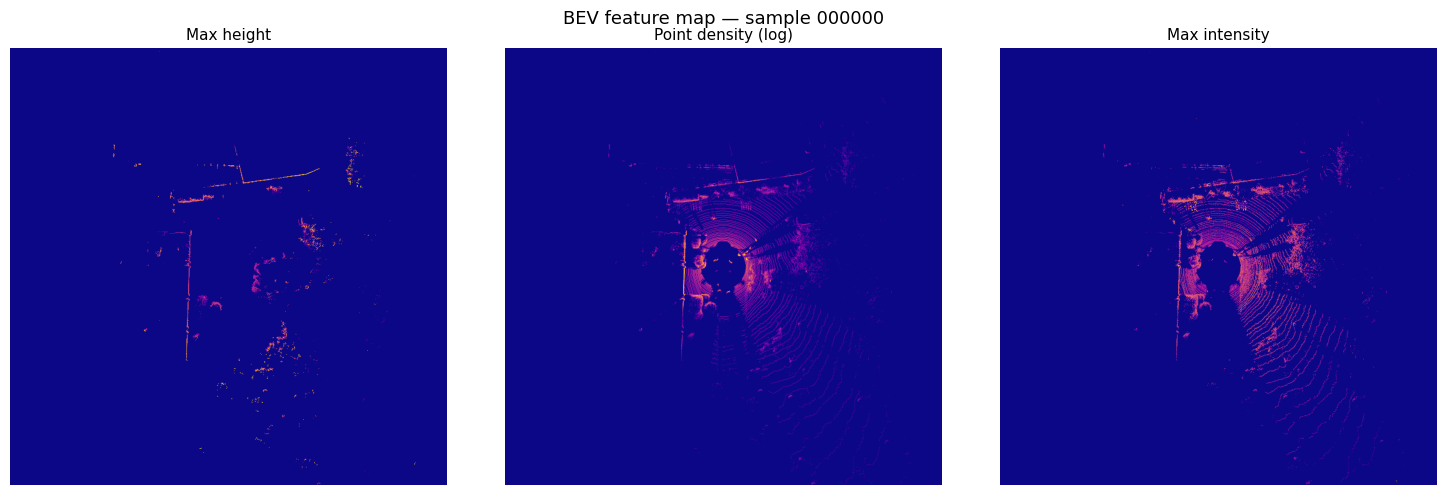

In [12]:
sid    = sample_ids[0]
pts    = load_point_cloud(TRAIN_DIR / 'velodyne' / f'{sid}.bin')
bev    = point_cloud_to_bev(pts, CFG)
print(f'Point cloud shape : {pts.shape}')
print(f'BEV map shape     : {bev.shape}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Max height', 'Point density (log)', 'Max intensity']
for ax, ch, title in zip(axes, [0, 2, 3], titles):
    ax.imshow(bev[ch], cmap='plasma', origin='lower')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle(f'BEV feature map — sample {sid}', fontsize=13)
plt.tight_layout()
plt.show()

## 4. KITTI Dataset Class

In [13]:
class KITTIFusionDataset(Dataset):
    """
    Returns:
      bev_map  : (5, H, W)  float32 BEV feature map
      img      : (3, img_h, img_w)  normalised RGB image
      boxes    : (N, 8)  [x,y,z,l,w,h,yaw,class_id] in LiDAR frame
      sample_id: str
    """

    IMG_MEAN = [0.485, 0.456, 0.406]
    IMG_STD  = [0.229, 0.224, 0.225]

    def __init__(self, data_dir, sample_ids, cfg, augment=False):
        self.data_dir   = Path(data_dir)
        self.sample_ids = sample_ids
        self.cfg        = cfg
        self.augment    = augment

        self.img_transform = T.Compose([
            T.Resize((cfg['img_h'], cfg['img_w'])),
            T.ToTensor(),
            T.Normalize(mean=self.IMG_MEAN, std=self.IMG_STD),
        ])

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sid = self.sample_ids[idx]

        # Load modalities 
        pts    = load_point_cloud(self.data_dir / 'velodyne' / f'{sid}.bin')
        img    = Image.open(self.data_dir / 'image_2'  / f'{sid}.png').convert('RGB')
        calib  = parse_calib(self.data_dir / 'calib'   / f'{sid}.txt')
        labels = parse_labels(self.data_dir / 'label_2' / f'{sid}.txt')

        # BEV 
        bev = point_cloud_to_bev(pts, self.cfg)           # (C, H, W)

        # Image 
        img_tensor = self.img_transform(img)              # (3, img_h, img_w)

        # GT boxes in LiDAR frame 
        boxes = get_lidar_boxes(labels, calib['V2C'])     # (N, 8)

        # ── Optional augmentation (horizontal flip) 
        if self.augment and random.random() > 0.5:
            bev        = np.flip(bev, axis=2).copy()     # flip W axis
            img_tensor = torch.flip(img_tensor, dims=[2]) # flip width
            if boxes.shape[0] > 0:
                boxes[:, 1]  = -boxes[:, 1]              # flip y
                boxes[:, 6]  = np.pi - boxes[:, 6]       # flip yaw

        return (
            torch.from_numpy(bev).float(),
            img_tensor,
            torch.from_numpy(boxes).float() if boxes.shape[0] > 0
                else torch.zeros((0, 8), dtype=torch.float32),
            sid
        )


def collate_fn(batch):
    """Custom collate: box lists have variable length."""
    bevs, imgs, boxes_list, ids = zip(*batch)
    return (
        torch.stack(bevs),
        torch.stack(imgs),
        list(boxes_list),
        list(ids)
    )


# train / val split 
random.seed(CFG['seed'])
all_ids   = sorted([p.stem for p in (TRAIN_DIR / 'velodyne').glob('*.bin')])
random.shuffle(all_ids)

n_val     = max(1, int(len(all_ids) * CFG['val_split']))
val_ids   = all_ids[:n_val]
train_ids = all_ids[n_val:]

train_dataset = KITTIFusionDataset(TRAIN_DIR, train_ids, CFG, augment=True)
val_dataset   = KITTIFusionDataset(TRAIN_DIR, val_ids,   CFG, augment=False)

train_loader  = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                           shuffle=True,  num_workers=2,
                           collate_fn=collate_fn, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=CFG['batch_size'],
                           shuffle=False, num_workers=2,
                           collate_fn=collate_fn, pin_memory=True)

print(f'Train: {len(train_dataset)} samples  ({len(train_loader)} batches)')
print(f'Val:   {len(val_dataset)}   samples  ({len(val_loader)}  batches)')

# Verify one batch
bev_b, img_b, boxes_b, ids_b = next(iter(train_loader))
print(f'\nBatch shapes:')
print(f'  BEV:   {bev_b.shape}')
print(f'  Image: {img_b.shape}')
print(f'  Boxes: {[b.shape for b in boxes_b]}')

Train: 6733 samples  (3367 batches)
Val:   748   samples  (374  batches)

Batch shapes:
  BEV:   torch.Size([2, 5, 800, 800])
  Image: torch.Size([2, 3, 384, 1280])
  Boxes: [torch.Size([2, 8]), torch.Size([11, 8])]


## 5. Model Architecture


In [14]:
# BEV Encoder
class BEVEncoder(nn.Module):
    def __init__(self, in_channels=5, out_channels=256):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1: 5 → 64, stride 2
            nn.Conv2d(in_channels, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),

            # Block 2: 64 → 128, stride 2
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),

            # Block 3: 128 → 256, stride 2
            nn.Conv2d(128, 256, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),

            # Block 4: 256 → out_channels, stride 1 (refine)
            nn.Conv2d(256, out_channels, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.encoder(x)   # (B, out_channels, H/8, W/8)

In [15]:
# Image Encoder — ResNet backbone
class ImageEncoder(nn.Module):
    def __init__(self, backbone_name='resnet18', out_channels=256, pretrained=True):
        super().__init__()

        # Load backbone
        backbone = getattr(models, backbone_name)(
            weights='DEFAULT' if pretrained else None)

        # Feature extractor: everything up to (but not including) avgpool
        # For resnet18/34: layer4 output is (B, 512, H/32, W/32)
        # We extract from layer3 for richer spatial resolution: (B, 256, H/16, W/16)
        self.stem   = nn.Sequential(backbone.conv1, backbone.bn1,
                                    backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3   # stride-16 features

        # Determine layer3 output channels
        layer3_out = 256 if backbone_name in ('resnet18', 'resnet34') else 1024

        # Project to uniform channel dimension
        self.proj = nn.Sequential(
            nn.Conv2d(layer3_out, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.proj(x)   # (B, out_channels, H/16, W/16)



In [28]:
class CrossAttentionFusion(nn.Module):
    """
    Memory-efficient cross-attention for large BEV maps.
    
    Key idea: spatially pool both BEV and image features to a small
    fixed resolution (pool_size × pool_size) before computing attention,
    then upsample the attended output back to the original BEV resolution.
    
    Memory: O(pool_size^4) instead of O(Hb^2 * Hi^2)
    With pool_size=25: 625^2 = 390k  vs  10000^2 = 100M  (256× reduction)
    """
    def __init__(self, channels=256, num_heads=4, dropout=0.1, pool_size=25):
        super().__init__()
        self.channels  = channels
        self.num_heads = num_heads
        self.pool_size = pool_size

        # Projections
        self.q_proj   = nn.Linear(channels, channels, bias=False)
        self.k_proj   = nn.Linear(channels, channels, bias=False)
        self.v_proj   = nn.Linear(channels, channels, bias=False)
        self.out_proj = nn.Linear(channels, channels, bias=False)

        self.dropout = nn.Dropout(dropout)
        self.norm1   = nn.LayerNorm(channels)
        self.norm2   = nn.LayerNorm(channels)

        self.ffn = nn.Sequential(
            nn.Linear(channels, channels * 2),   # smaller FFN (was ×4)
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(channels * 2, channels),
            nn.Dropout(dropout),
        )

    def forward(self, bev_feat, img_feat):
        """
        bev_feat : (B, C, Hb, Wb)
        img_feat : (B, C, Hi, Wi)   — already resized to match BEV in BEVFusionDetector
        Returns  : (B, C, Hb, Wb)
        """
        B, C, Hb, Wb = bev_feat.shape

        # ── 1. Pool both feature maps to pool_size × pool_size ─────────
        #    adaptive_avg_pool2d is differentiable and fast
        bev_pool = F.adaptive_avg_pool2d(bev_feat, self.pool_size)  # (B,C,P,P)
        img_pool = F.adaptive_avg_pool2d(img_feat, self.pool_size)  # (B,C,P,P)
        P2 = self.pool_size * self.pool_size  # number of tokens (e.g. 625)

        # ── 2. Flatten to sequences ─────────────────────────────────────
        q = bev_pool.flatten(2).transpose(1, 2)  # (B, P², C)
        k = img_pool.flatten(2).transpose(1, 2)  # (B, P², C)
        v = k

        # ── 3. Project ──────────────────────────────────────────────────
        q = self.q_proj(q)
        k = self.k_proj(k)
        v = self.v_proj(v)

        # ── 4. Multi-head split ─────────────────────────────────────────
        head_dim = C // self.num_heads
        def split_heads(t):
            return t.view(B, P2, self.num_heads, head_dim).transpose(1, 2)
        q, k, v = split_heads(q), split_heads(k), split_heads(v)
        # shape: (B, num_heads, P², head_dim)

        # ── 5. Scaled dot-product attention ─────────────────────────────
        #    Matrix is now (B, H, 625, 625) = ~12 MB in fp16  ✓
        scale  = head_dim ** -0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale
        attn   = self.dropout(F.softmax(scores, dim=-1))
        out    = torch.matmul(attn, v)   # (B, H, P², head_dim)

        # Merge heads
        out = out.transpose(1, 2).contiguous().view(B, P2, C)
        out = self.out_proj(out)

        # Residual + LayerNorm 
        bev_q = bev_pool.flatten(2).transpose(1, 2)   # (B, P², C)
        out   = self.norm1(bev_q + out)
        out   = self.norm2(out + self.ffn(out))

        # ── 8. Reshape back to spatial → (B, C, P, P) ───────────────────
        out = out.transpose(1, 2).view(B, C, self.pool_size, self.pool_size)

        # ── 9. Upsample attended features back to original BEV size ─────
        #    Bilinear upsample is memory-efficient (no learned weights)
        out = F.interpolate(out, size=(Hb, Wb), mode='bilinear', align_corners=False)

        # ── 10. Residual skip from full-res BEV features ─────────────────
        #    This preserves fine-grained BEV spatial detail
        out = out + bev_feat

        return out

In [19]:
class DetectionHead(nn.Module):
    def __init__(self, in_channels=256, num_classes=3):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.cls_head = nn.Conv2d(256, num_classes, 1)
        self.reg_head = nn.Conv2d(256, 8, 1)  # dx,dy,dz,log_l,log_w,log_h,sin,cos

    def forward(self, x):
        feat     = self.shared(x)
        cls_pred = self.cls_head(feat)   # (B, num_classes, H, W)
        reg_pred = self.reg_head(feat)   # (B, 8, H, W)
        return cls_pred, reg_pred

In [20]:
class BEVFusionDetector(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        C = cfg['feat_channels']

        self.bev_encoder   = BEVEncoder(in_channels=cfg['bev_channels'],
                                        out_channels=C)
        self.img_encoder   = ImageEncoder(backbone_name=cfg['backbone'],
                                          out_channels=C)
        self.cross_attn    = CrossAttentionFusion(channels=C,
                                                  num_heads=cfg['num_heads'])
        # Adaptive pool to align spatial dims before attention
        # BEV: (H/8, W/8);  Image features at different size → we resize img feats
        self.det_head      = DetectionHead(in_channels=C,
                                           num_classes=cfg['num_classes'])

    def forward(self, bev, img):
        # Encode 
        bev_feat = self.bev_encoder(bev)   # (B, C, Hb, Wb)
        img_feat = self.img_encoder(img)   # (B, C, Hi, Wi)

        # Resize image features to match BEV spatial dims
        img_feat = F.interpolate(img_feat,
                                 size=bev_feat.shape[2:],
                                 mode='bilinear', align_corners=False)

        # Cross-attention fusion 
        fused = self.cross_attn(bev_feat, img_feat)   # (B, C, Hb, Wb)

        # Detection head
        cls_pred, reg_pred = self.det_head(fused)
        return cls_pred, reg_pred

In [29]:
model = BEVFusionDetector(CFG).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params/1e6:.2f} M')

# Quick forward pass check
bev_dummy = torch.randn(2, CFG['bev_channels'], CFG['bev_h'], CFG['bev_w']).to(device)
img_dummy = torch.randn(2, 3, CFG['img_h'], CFG['img_w']).to(device)
with torch.no_grad():
    cls_out, reg_out = model(bev_dummy, img_dummy)
print(f'\nForward pass OK')
print(f'  cls_pred: {cls_out.shape}   (B, num_classes, H/8, W/8)')
print(f'  reg_pred: {reg_out.shape}   (B, 8,           H/8, W/8)')

Model parameters: 5.52 M

Forward pass OK
  cls_pred: torch.Size([2, 3, 50, 50])   (B, num_classes, H/8, W/8)
  reg_pred: torch.Size([2, 8, 50, 50])   (B, 8,           H/8, W/8)


## 6. Loss Functions

In [43]:
# Target assignment
def assign_targets(boxes_list, cls_pred, reg_pred, cfg):
    """
    boxes_list : list of (Ni, 8) tensors  [x,y,z,l,w,h,yaw,class_id]
    cls_pred   : (B, num_classes, H, W)
    reg_pred   : (B, 8, H, W)

    Returns:
      cls_target : (B, H, W)          long  — class index or -1 (ignore)
      reg_target : (B, 8, H, W)       float
      pos_mask   : (B, H, W)          bool
    """
    B, _, H, W = cls_pred.shape
    x_min, x_max = cfg['bev_x_range']
    y_min, y_max = cfg['bev_y_range']
    stride       = cfg['bev_resolution'] * 8   # feature map stride = 8×

    cls_target = torch.full((B, H, W), -1, dtype=torch.long,  device=cls_pred.device)
    reg_target = torch.zeros((B, 8, H, W),  dtype=torch.float32, device=cls_pred.device)
    pos_mask   = torch.zeros((B, H, W),     dtype=torch.bool,    device=cls_pred.device)

    for b, boxes in enumerate(boxes_list):
        if boxes.shape[0] == 0:
            continue
        boxes = boxes.to(cls_pred.device)

        # Centre of box in BEV feature-map coordinates
        bx = ((boxes[:, 0] - x_min) / stride).long()   # x → row
        by = ((boxes[:, 1] - y_min) / stride).long()   # y → col

        valid = (bx >= 0) & (bx < H) & (by >= 0) & (by < W)
        bx, by, boxes = bx[valid], by[valid], boxes[valid]

        cls_target[b, bx, by] = boxes[:, 7].long()   # class id
        pos_mask[b, bx, by]   = True

        # Regression targets (offsets from cell centre)
        cx = x_min + (bx.float() + 0.5) * stride
        cy = y_min + (by.float() + 0.5) * stride
        dx  = boxes[:, 0] - cx
        dy  = boxes[:, 1] - cy
        dz  = boxes[:, 2]
        log_l = torch.log(boxes[:, 3].clamp(min=0.01))
        log_w = torch.log(boxes[:, 4].clamp(min=0.01))
        log_h = torch.log(boxes[:, 5].clamp(min=0.01))
        sin_y = torch.sin(boxes[:, 6])
        cos_y = torch.cos(boxes[:, 6])

        for i in range(len(bx)):
            reg_target[b, :, bx[i], by[i]] = torch.stack(
                [dx[i], dy[i], dz[i], log_l[i], log_w[i], log_h[i], sin_y[i], cos_y[i]])

    # Background cells get class 0 label for focal loss
    cls_target[cls_target == -1] = cfg['num_classes']   # background index
    return cls_target, reg_target, pos_mask


# Focal Loss  (handles class imbalance; α and γ are tunable)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, num_classes=3):
        super().__init__()
        self.alpha       = alpha
        self.gamma       = gamma
        self.num_classes = num_classes

    def forward(self, pred, target):
        """
        pred   : (B, num_classes, H, W)
        target : (B, H, W)  — class index in [0, num_classes-1] for fg, num_classes for bg
        """
        B, C, H, W = pred.shape

        # Build binary targets: shape (B, C, H, W)
        fg_mask = (target < self.num_classes).unsqueeze(1)          # (B,1,H,W)
        tgt_cls = target.clamp(0, C - 1).unsqueeze(1)               # (B,1,H,W)
        tgt_oh  = torch.zeros_like(pred)
        tgt_oh.scatter_(1, tgt_cls, fg_mask.float())                 # 1 only at fg class

        # Numerically stable focal loss via log-sum-exp trick
        p        = torch.sigmoid(pred)
        ce_pos   = F.binary_cross_entropy_with_logits(pred,  tgt_oh,      reduction='none')
        ce_neg   = F.binary_cross_entropy_with_logits(pred,  torch.zeros_like(pred), reduction='none')

        p_t      = p * tgt_oh + (1 - p) * (1 - tgt_oh)
        alpha_t  = self.alpha * tgt_oh + (1 - self.alpha) * (1 - tgt_oh)
        fl       = alpha_t * (1 - p_t).pow(self.gamma) * ce_pos

        # Only penalise background on non-ignored cells
        # Separate fg and bg loss so bg doesn't dominate
        n_fg     = tgt_oh.sum().clamp(min=1)
        n_bg     = (1 - tgt_oh).sum().clamp(min=1)
        fg_loss  = (fl      * tgt_oh     ).sum() / n_fg
        bg_loss  = (fl      * (1-tgt_oh) ).sum() / n_bg

        return fg_loss + 0.1 * bg_loss   # down-weight bg term heavily




In [25]:
# Combined Detection Loss
class DetectionLoss(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg         = cfg
        self.focal_loss  = FocalLoss(num_classes=cfg['num_classes'])
        self.smooth_l1   = nn.SmoothL1Loss(reduction='none')

    def forward(self, cls_pred, reg_pred, boxes_list):
        cls_target, reg_target, pos_mask = assign_targets(
            boxes_list, cls_pred, reg_pred, self.cfg)

        # Classification loss 
        cls_loss = self.focal_loss(cls_pred, cls_target)

        # Regression loss (only on positive cells) 
        n_pos = pos_mask.sum().clamp(min=1)
        reg_loss_map = self.smooth_l1(reg_pred, reg_target)   # (B,8,H,W)
        reg_loss     = (reg_loss_map * pos_mask.unsqueeze(1).float()).sum() / n_pos

        total = self.cfg['cls_weight'] * cls_loss + self.cfg['reg_weight'] * reg_loss
        return total, cls_loss.item(), reg_loss.item()


criterion = DetectionLoss(CFG)


## 7. Training Loop

In [44]:
# Optimiser & scheduler 
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay']
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG['num_epochs'],
    eta_min=CFG['lr'] * 0.01
)


# Mixed precision scaler 
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch):
    model.train()
    torch.cuda.empty_cache()  
    total_loss = cls_total = reg_total = 0.0
    t0 = time.time()

    for step, (bev, img, boxes, _) in enumerate(loader):
        bev = bev.to(device, non_blocking=True)
        img = img.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            cls_pred, reg_pred = model(bev, img)
            loss, cls_l, reg_l = criterion(cls_pred, reg_pred, boxes)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        cls_total  += cls_l
        reg_total  += reg_l

        if (step + 1) % 50 == 0:
            elapsed = time.time() - t0
            print(f'  Epoch {epoch:2d} | step {step+1:4d}/{len(loader)} '
                  f'| loss {total_loss/(step+1):.4f} '
                  f'(cls {cls_total/(step+1):.4f}, '
                  f'reg {reg_total/(step+1):.4f}) '
                  f'| {elapsed:.1f}s')

    n = len(loader)
    return total_loss / n, cls_total / n, reg_total / n


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss = cls_total = reg_total = 0.0

    for bev, img, boxes, _ in loader:
        bev = bev.to(device, non_blocking=True)
        img = img.to(device, non_blocking=True)
        cls_pred, reg_pred = model(bev, img)
        loss, cls_l, reg_l = criterion(cls_pred, reg_pred, boxes)
        total_loss += loss.item()
        cls_total  += cls_l
        reg_total  += reg_l

    n = len(loader)
    return total_loss / n, cls_total / n, reg_total / n


# Main training loop 
history = defaultdict(list)
best_val_loss = float('inf')
CKPT_PATH = '/kaggle/working/best_model.pth'

print(f'Starting training for {CFG["num_epochs"]} epochs on {device}')
print('=' * 65)

for epoch in range(1, CFG['num_epochs'] + 1):
    t_ep = time.time()

    train_loss, train_cls, train_reg = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, epoch)

    val_loss, val_cls, val_reg = validate(model, val_loader, criterion)
    scheduler.step()

    # Record
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch':      epoch,
            'model':      model.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'val_loss':   val_loss,
            'cfg':        CFG,
        }, CKPT_PATH)
        flag = ' best'
    else:
        flag = ''

    ep_time = time.time() - t_ep
    print(f'Epoch {epoch:2d}/{CFG["num_epochs"]}  '
          f'train {train_loss:.4f}  val {val_loss:.4f}  '
          f'[{ep_time:.0f}s]{flag}')

print('\nTraining complete.')
print(f'Best checkpoint saved to: {CKPT_PATH}')

Starting training for 30 epochs on cuda
  Epoch  1 | step   50/3367 | loss 0.5945 (cls 0.0001, reg 0.2972) | 7.2s
  Epoch  1 | step  100/3367 | loss 0.4799 (cls 0.0001, reg 0.2399) | 14.0s
  Epoch  1 | step  150/3367 | loss 0.5317 (cls 0.0001, reg 0.2658) | 20.6s
  Epoch  1 | step  200/3367 | loss 0.5117 (cls 0.0001, reg 0.2558) | 27.3s
  Epoch  1 | step  250/3367 | loss 0.5377 (cls 0.0001, reg 0.2688) | 34.0s
  Epoch  1 | step  300/3367 | loss 0.5379 (cls 0.0001, reg 0.2689) | 40.5s
  Epoch  1 | step  350/3367 | loss 0.5356 (cls 0.0001, reg 0.2678) | 47.2s
  Epoch  1 | step  400/3367 | loss 0.5326 (cls 0.0001, reg 0.2663) | 53.7s
  Epoch  1 | step  450/3367 | loss 0.5320 (cls 0.0001, reg 0.2659) | 60.3s
  Epoch  1 | step  500/3367 | loss 0.5360 (cls 0.0001, reg 0.2680) | 66.9s
  Epoch  1 | step  550/3367 | loss 0.5318 (cls 0.0001, reg 0.2659) | 73.6s
  Epoch  1 | step  600/3367 | loss 0.5341 (cls 0.0001, reg 0.2670) | 80.2s
  Epoch  1 | step  650/3367 | loss 0.5387 (cls 0.0001, reg 0.

KeyboardInterrupt: 

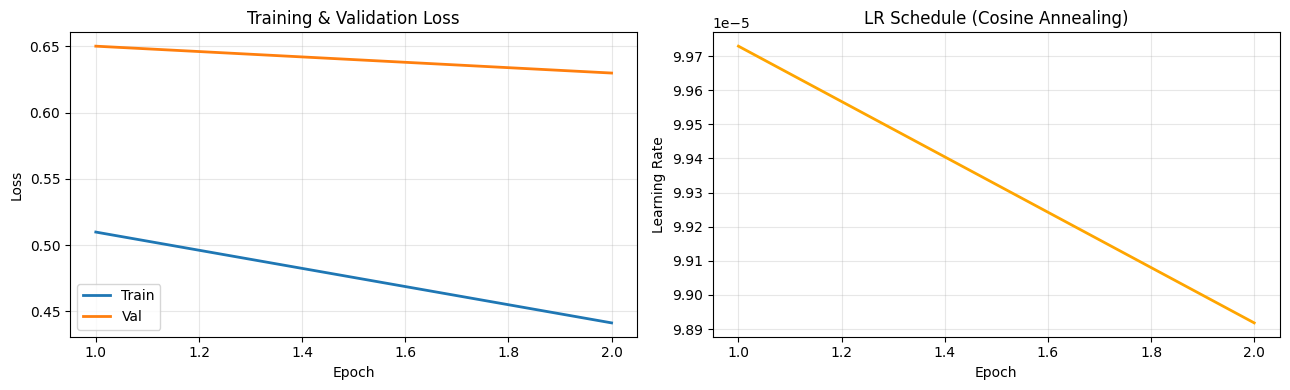

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   label='Val',   linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['lr'], color='orange', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('LR Schedule (Cosine Annealing)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=120)
plt.show()

## 8. Post-proecssing & Inference

In [46]:
# Decode raw model outputs into 3D bounding boxes
def decode_predictions(cls_pred, reg_pred, cfg, score_thresh=0.3, nms_iou=0.3):
    """
    cls_pred   : (B, num_classes, H, W)
    reg_pred   : (B, 8, H, W)

    Returns list of B dicts, each with:
      'boxes'   : (N, 7) [x,y,z,l,w,h,yaw]
      'scores'  : (N,)
      'classes' : (N,)  int
    """
    B, C, H, W = cls_pred.shape
    x_min, _   = cfg['bev_x_range']
    y_min, _   = cfg['bev_y_range']
    stride     = cfg['bev_resolution'] * 8

    # Grid cell centres
    row_idx = torch.arange(H, device=cls_pred.device)
    col_idx = torch.arange(W, device=cls_pred.device)
    grid_x  = x_min + (row_idx.float() + 0.5) * stride  # (H,)
    grid_y  = y_min + (col_idx.float() + 0.5) * stride  # (W,)
    gx, gy  = torch.meshgrid(grid_x, grid_y, indexing='ij')  # (H, W)

    scores_all  = torch.sigmoid(cls_pred)   # (B, C, H, W)
    results = []

    for b in range(B):
        # Best class per cell
        cls_scores, cls_ids = scores_all[b].max(dim=0)   # (H, W)
        keep_mask           = cls_scores > score_thresh

        if keep_mask.sum() == 0:
            results.append({'boxes': np.zeros((0,7)), 'scores': np.zeros(0), 'classes': np.zeros(0, int)})
            continue

        # Decode boxes
        reg = reg_pred[b]                           # (8, H, W)
        xs  = (gx + reg[0])[keep_mask].cpu().numpy()
        ys  = (gy + reg[1])[keep_mask].cpu().numpy()
        zs  = reg[2][keep_mask].cpu().numpy()
        ls  = torch.exp(reg[3])[keep_mask].cpu().numpy()
        ws  = torch.exp(reg[4])[keep_mask].cpu().numpy()
        hs  = torch.exp(reg[5])[keep_mask].cpu().numpy()
        yaw = torch.atan2(reg[6], reg[7])[keep_mask].cpu().numpy()

        boxes   = np.stack([xs, ys, zs, ls, ws, hs, yaw], axis=1)
        scores  = cls_scores[keep_mask].cpu().numpy()
        classes = cls_ids[keep_mask].cpu().numpy()

        # BEV-NMS (simple IoU over BEV rectangles) 
        boxes, scores, classes = bev_nms(boxes, scores, classes, iou_thresh=nms_iou)

        results.append({'boxes': boxes, 'scores': scores, 'classes': classes})

    return results


def bev_nms(boxes, scores, classes, iou_thresh=0.3):
    """Simple greedy NMS in BEV (using axis-aligned bounding boxes for speed)."""
    if len(boxes) == 0:
        return boxes, scores, classes

    order = np.argsort(-scores)
    keep  = []

    while len(order) > 0:
        i = order[0]
        keep.append(i)
        if len(order) == 1:
            break

        # Compute pairwise BEV IoU (axis-aligned approximation)
        iou = bev_iou(boxes[i], boxes[order[1:]])
        order = order[1:][iou < iou_thresh]

    keep = np.array(keep)
    return boxes[keep], scores[keep], classes[keep]


def bev_iou(box_ref, boxes_others):
    """Compute IoU of box_ref vs each box in boxes_others in BEV (axis-aligned)."""
    # box: [x, y, z, l, w, h, yaw]  — use l and w for BEV footprint
    def corners(b):
        return np.array([
            b[0] - b[3]/2, b[1] - b[4]/2,
            b[0] + b[3]/2, b[1] + b[4]/2
        ])

    r  = corners(box_ref)
    ious = []
    for b in boxes_others:
        o = corners(b)
        ix1, iy1 = max(r[0], o[0]), max(r[1], o[1])
        ix2, iy2 = min(r[2], o[2]), min(r[3], o[3])
        inter = max(0, ix2-ix1) * max(0, iy2-iy1)
        area_r = (r[2]-r[0]) * (r[3]-r[1])
        area_o = (o[2]-o[0]) * (o[3]-o[1])
        ious.append(inter / (area_r + area_o - inter + 1e-6))
    return np.array(ious)



Loaded best checkpoint (epoch 3, val_loss 0.6421)


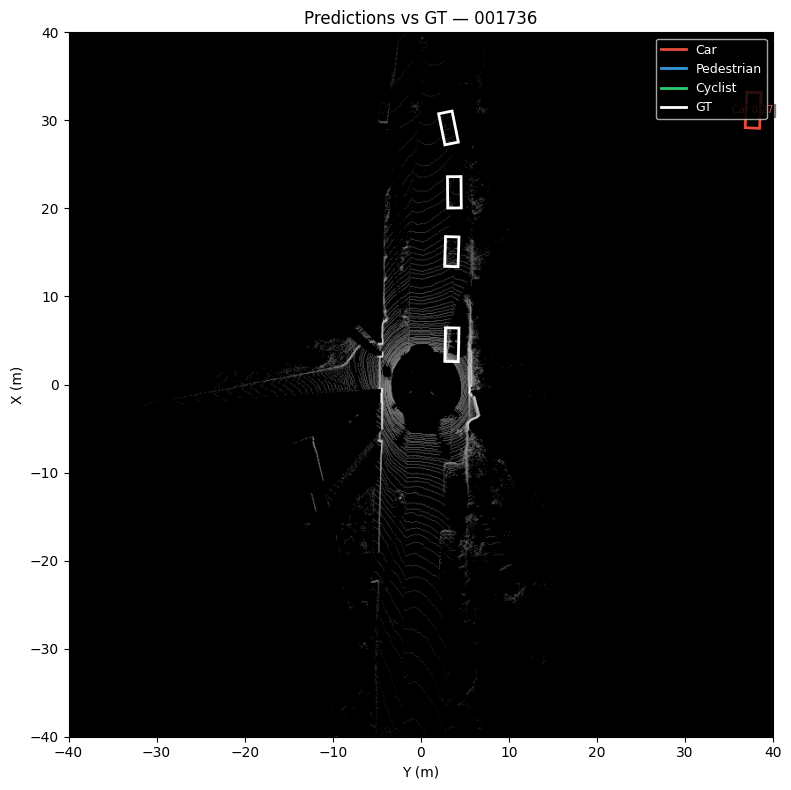

In [38]:
CLASS_NAMES  = ['Car', 'Pedestrian', 'Cyclist']
CLASS_COLORS = ['#e74c3c', '#3498db', '#2ecc71']


def visualise_bev_predictions(bev_map, pred_boxes, gt_boxes=None, title=''):
    """
    bev_map   : (5, H, W) numpy array
    pred_boxes: dict with 'boxes', 'scores', 'classes'
    gt_boxes  : (N, 8) numpy array [x,y,z,l,w,h,yaw,class_id]  (optional)
    """
    density = bev_map[2]   # log-normalised density channel
    H, W    = density.shape

    cfg = CFG
    x_min, x_max = cfg['bev_x_range']
    y_min, y_max = cfg['bev_y_range']
    res          = cfg['bev_resolution']
    stride       = res * 8

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(density, cmap='gray', origin='lower',
              extent=[y_min, y_max, x_min, x_max])

    def draw_box_bev(ax, box, color, label=None):
        x, y, z, l, w, h, yaw = box[:7]
        # Rotate corners
        corners = np.array([
            [-l/2, -w/2], [ l/2, -w/2],
            [ l/2,  w/2], [-l/2,  w/2]
        ])
        c, s = np.cos(yaw), np.sin(yaw)
        R = np.array([[c, -s], [s, c]])
        corners = (R @ corners.T).T + np.array([x, y])
        poly = plt.Polygon(corners[:, ::-1], fill=False,
                           edgecolor=color, linewidth=2)
        ax.add_patch(poly)
        if label:
            ax.text(y, x, label, color=color, fontsize=7,
                    ha='center', va='center',
                    bbox=dict(fc='black', alpha=0.4, pad=1))

    # Draw GT boxes (white, dashed)
    if gt_boxes is not None and len(gt_boxes) > 0:
        for box in gt_boxes:
            draw_box_bev(ax, box, color='white')

    # Draw predicted boxes
    boxes   = pred_boxes.get('boxes',   [])
    scores  = pred_boxes.get('scores',  [])
    classes = pred_boxes.get('classes', [])
    for box, score, cls_id in zip(boxes, scores, classes):
        color = CLASS_COLORS[cls_id % len(CLASS_COLORS)]
        label = f"{CLASS_NAMES[cls_id]} {score:.2f}"
        draw_box_bev(ax, box, color=color, label=label)

    # Legend
    from matplotlib.lines import Line2D
    legend = [Line2D([0],[0], color=c, lw=2, label=n)
              for n, c in zip(CLASS_NAMES, CLASS_COLORS)]
    legend += [Line2D([0],[0], color='white', lw=2, label='GT')]
    ax.legend(handles=legend, loc='upper right', fontsize=9,
              facecolor='black', labelcolor='white')

    ax.set_xlim(y_min, y_max)
    ax.set_ylim(x_min, x_max)
    ax.set_xlabel('Y (m)'); ax.set_ylabel('X (m)')
    ax.set_title(title or 'BEV predictions')
    plt.tight_layout()
    plt.show()


# ─── Load best checkpoint and run inference on a val sample 
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.4f})")

# Run on one validation sample
sid   = val_ids[0]
ds    = val_dataset
bev_s, img_s, boxes_gt, _ = ds[0]

with torch.no_grad():
    cls_p, reg_p = model(
        bev_s.unsqueeze(0).to(device),
        img_s.unsqueeze(0).to(device)
    )
preds = decode_predictions(cls_p, reg_p, CFG, score_thresh=0.25)

visualise_bev_predictions(
    bev_s.numpy(),
    preds[0],
    gt_boxes=boxes_gt.numpy(),
    title=f'Predictions vs GT — {sid}'
)

## 9. Evaluation (mAP)

In [47]:
# BEV IoU between a single prediction and all GTs of the same class
def compute_ap(recalls, precisions):
    """Compute area under precision-recall curve (11-point interpolation)."""
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        p = precisions[recalls >= t]
        ap += (p.max() if len(p) > 0 else 0.0)
    return ap / 11


@torch.no_grad()
def evaluate(model, loader, cfg, iou_thresh=0.5, score_thresh=0.1):
    """
    Returns per-class AP and mAP.
    """
    model.eval()
    all_preds = defaultdict(list)   # class_id → [(score, tp/fp), ...]
    all_gt_counts = defaultdict(int)

    for bev, img, boxes_list, _ in loader:
        bev = bev.to(device)
        img = img.to(device)

        cls_p, reg_p = model(bev, img)
        preds = decode_predictions(cls_p, reg_p, cfg,
                                   score_thresh=score_thresh, nms_iou=0.3)

        for b, (pred, gt) in enumerate(zip(preds, boxes_list)):
            gt_np = gt.numpy()

            # Count GT per class
            for cls_id in range(cfg['num_classes']):
                all_gt_counts[cls_id] += int((gt_np[:, 7] == cls_id).sum())

            if len(pred['boxes']) == 0:
                continue

            # Sort by score descending
            sort_idx = np.argsort(-pred['scores'])
            p_boxes   = pred['boxes'][sort_idx]
            p_scores  = pred['scores'][sort_idx]
            p_classes = pred['classes'][sort_idx]

            matched = np.zeros(len(gt_np), dtype=bool)

            for pb, ps, pc in zip(p_boxes, p_scores, p_classes):
                gt_same = np.where(gt_np[:, 7] == pc)[0]
                if len(gt_same) == 0:
                    all_preds[pc].append((ps, 0))
                    continue

                ious  = bev_iou(pb, gt_np[gt_same])
                best  = ious.argmax()
                if ious[best] >= iou_thresh and not matched[gt_same[best]]:
                    matched[gt_same[best]] = True
                    all_preds[pc].append((ps, 1))   # TP
                else:
                    all_preds[pc].append((ps, 0))   # FP

    # ── Compute AP per class 
    aps = {}
    for cls_id in range(cfg['num_classes']):
        entries = all_preds[cls_id]
        n_gt    = all_gt_counts[cls_id]

        if n_gt == 0 or len(entries) == 0:
            aps[cls_id] = 0.0
            continue

        entries = sorted(entries, key=lambda x: -x[0])
        tp_cum  = np.cumsum([e[1] for e in entries])
        fp_cum  = np.cumsum([1 - e[1] for e in entries])

        precisions = tp_cum / (tp_cum + fp_cum + 1e-6)
        recalls    = tp_cum / (n_gt + 1e-6)

        aps[cls_id] = compute_ap(recalls, precisions)

    mAP = np.mean(list(aps.values()))
    return aps, mAP


print('Running evaluation on validation set...')
aps, mAP = evaluate(model, val_loader, CFG, iou_thresh=CFG['iou_threshold'])

print('\n' + '─' * 35)
print(f'{"Class":<15}  {"AP@0.5":>8}')
print('─' * 35)
for cls_id, ap in aps.items():
    print(f'{CLASS_NAMES[cls_id]:<15}  {ap*100:8.2f}%')
print('─' * 35)
print(f'{"mAP":<15}  {mAP*100:8.2f}%')

Running evaluation on validation set...

───────────────────────────────────
Class              AP@0.5
───────────────────────────────────
Car                  0.00%
Pedestrian           0.00%
Cyclist              0.00%
───────────────────────────────────
mAP                  0.00%


### export as ONNX

In [ ]:
model.eval()
bev_dummy  = torch.randn(1, CFG['bev_channels'], CFG['bev_h'], CFG['bev_w']).to(device)
img_dummy  = torch.randn(1, 3, CFG['img_h'], CFG['img_w']).to(device)
onnx_path  = '/kaggle/working/bev_fusion_model.onnx'

torch.onnx.export(
    model,
    (bev_dummy, img_dummy),
    onnx_path,
    input_names=['bev_map', 'image'],
    output_names=['cls_pred', 'reg_pred'],
    opset_version=14,
    dynamic_axes={
        'bev_map':  {0: 'batch'},
        'image':    {0: 'batch'},
        'cls_pred': {0: 'batch'},
        'reg_pred': {0: 'batch'},
    }
)
print(f'ONNX model saved to {onnx_path}')